# Week 03 — Determinant: Vizual İntuisiya

**Bu notebook-un məqsədi:** Determinantın həndəsi mənasını **vizual sübutla** göstərmək. Hər qrafik özü-özünə danışmalıdır.

**Ana sual:** *Determinant nədir?*

**Cavab:** Determinant bir matrisi bir ədədə yığır — və bu ədəd həmin matrisin müstəvinin (və ya fəzanın) **necə dəyişdirdiyini** ölçür:
- **|det|** → sahənin (həcmin) neçə dəfə dəyişdiyini göstərir
- **işarə(det)** → orientasiyanın qorunub-qorunmadığını göstərir
- **det = 0** → matris müstəvini bir xəttə (və ya nöqtəyə) sıxır → informasiya itir

Bu konsepləri bir-bir vizuallaşdırırıq.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Standart vizual ayarlar — bütün notebook üçün
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Rəng paleti — bütün notebook-da istifadə edəcəyik
COLOR_ORIGINAL = '#3498db'    # mavi — orijinal kvadrat
COLOR_TRANSFORMED = '#e74c3c' # qırmızı — paraleloqram (det > 0)
COLOR_FLIPPED = '#9b59b6'     # bənövşəyi — flipped (det < 0)
COLOR_NULL = '#27ae60'        # yaşıl — null space
COLOR_COLUMN = '#e67e22'      # narıncı — column space

---
## 1️⃣ Əsas Vizual — Vahid Kvadrat → 5 Fərqli Paraleloqram

Vahid kvadrat (sahə = 1) götürürük və 5 fərqli matris tətbiq edirik. Hər birində paraleloqramın sahəsi dəqiq **|det|**-ə bərabər olur.

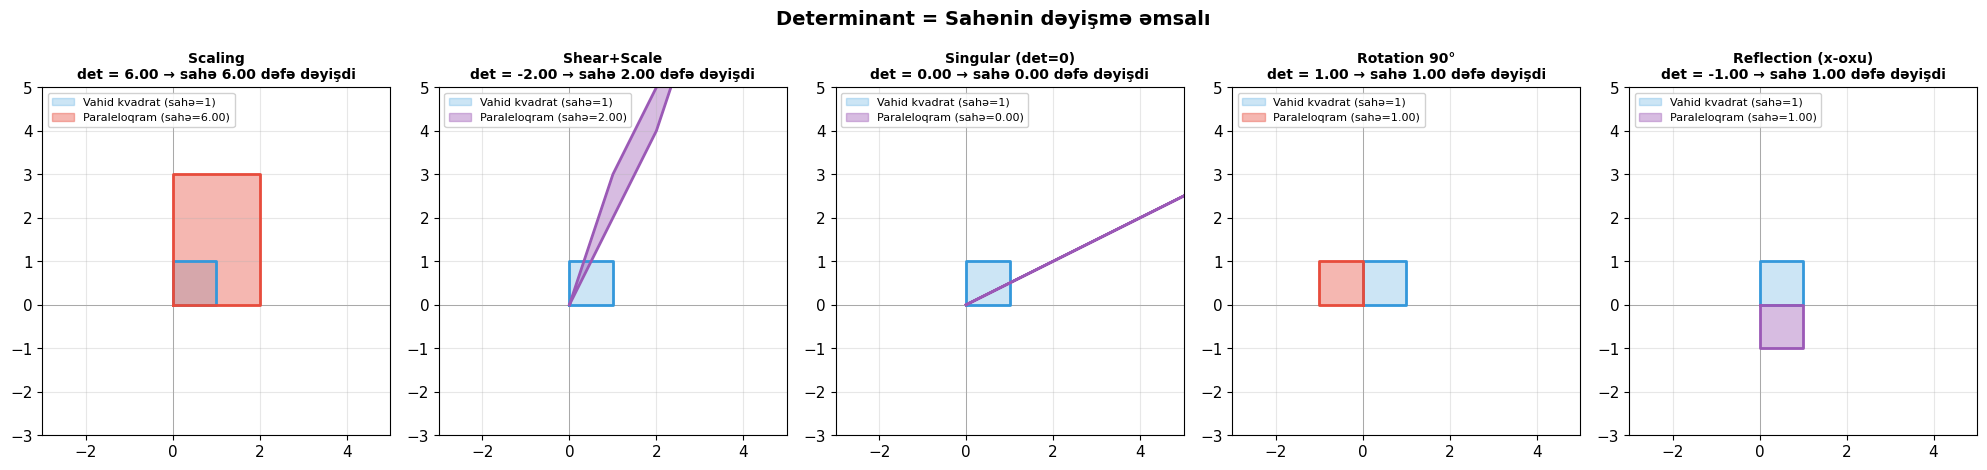

In [2]:
def apply_transform(M):
    """Vahid kvadratın 4 küncünü matrislə transformasiya et."""
    # Küncləri sıra ilə: (0,0), (1,0), (1,1), (0,1), və geri (0,0)
    corners = np.array([
        [0, 1, 1, 0, 0],
        [0, 0, 1, 1, 0]
    ])
    return M @ corners

def plot_unit_square(ax):
    """Vahid kvadratı çək."""
    square = np.array([[0, 1, 1, 0, 0], [0, 0, 1, 1, 0]])
    ax.fill(square[0], square[1], alpha=0.25, color=COLOR_ORIGINAL,
            label='Vahid kvadrat (sahə=1)')
    ax.plot(square[0], square[1], '-', color=COLOR_ORIGINAL, linewidth=2)

def plot_transformation(ax, M, title):
    """Vahid kvadratı və transformasiyanı çək."""
    plot_unit_square(ax)
    
    transformed = apply_transform(M)
    det = np.linalg.det(M)
    color = COLOR_TRANSFORMED if det > 0 else COLOR_FLIPPED
    
    ax.fill(transformed[0], transformed[1], alpha=0.4, color=color,
            label=f'Paraleloqram (sahə={abs(det):.2f})')
    ax.plot(transformed[0], transformed[1], '-', color=color, linewidth=2)
    
    # Oxlar
    ax.axhline(0, color='gray', linewidth=0.5, zorder=0)
    ax.axvline(0, color='gray', linewidth=0.5, zorder=0)
    
    # Başlıq — tapşırıq formatı
    sign = '+' if det >= 0 else '−'
    ax.set_title(f'{title}\ndet = {det:.2f} → sahə {abs(det):.2f} dəfə dəyişdi',
                 fontsize=10, fontweight='bold')
    
    ax.set_aspect('equal')
    ax.legend(loc='upper left', fontsize=8, framealpha=0.9)

# 5 matris
matrices = [
    (np.array([[2, 0], [0, 3]]),    'Scaling'),
    (np.array([[1, 2], [3, 4]]),    'Shear+Scale'),
    (np.array([[2, 4], [1, 2]]),    'Singular (det=0)'),
    (np.array([[0, -1], [1, 0]]),   'Rotation 90°'),
    (np.array([[1, 0], [0, -1]]),   'Reflection (x-oxu)'),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))
for ax, (M, name) in zip(axes, matrices):
    plot_transformation(ax, M, name)
    ax.set_xlim(-3, 5)
    ax.set_ylim(-3, 5)

plt.suptitle('Determinant = Sahənin dəyişmə əmsalı',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_main_visual.png', dpi=120, bbox_inches='tight')
plt.show()

**📌 İzah:** Mavi vahid kvadrat (sahə = 1) hər matrislə fərqli paraleloqrama çevrilir. Paraleloqramın sahəsi **dəqiq |det|**-ə bərabərdir. Scaling sahəni 6 dəfə artırır, rotation sahəni qoruyur (det=1), reflection da sahəni qoruyur amma **bənövşəyi rəng** mənfi det-i göstərir — yön çevrildi. Singular matrisdə paraleloqram düz xəttə yıxılır (sahə=0).

---
## 2️⃣ Müsbət vs Mənfi det — Orientasiya Çevrilməsi

Künclərə 1,2,3,4 nömrə qoyaraq orientasiyanın necə dəyişdiyini göstərək. Mənfi det olanda nömrələrin sırası saat əqrəbinin əksindən saat əqrəbi istiqamətinə dəyişir.

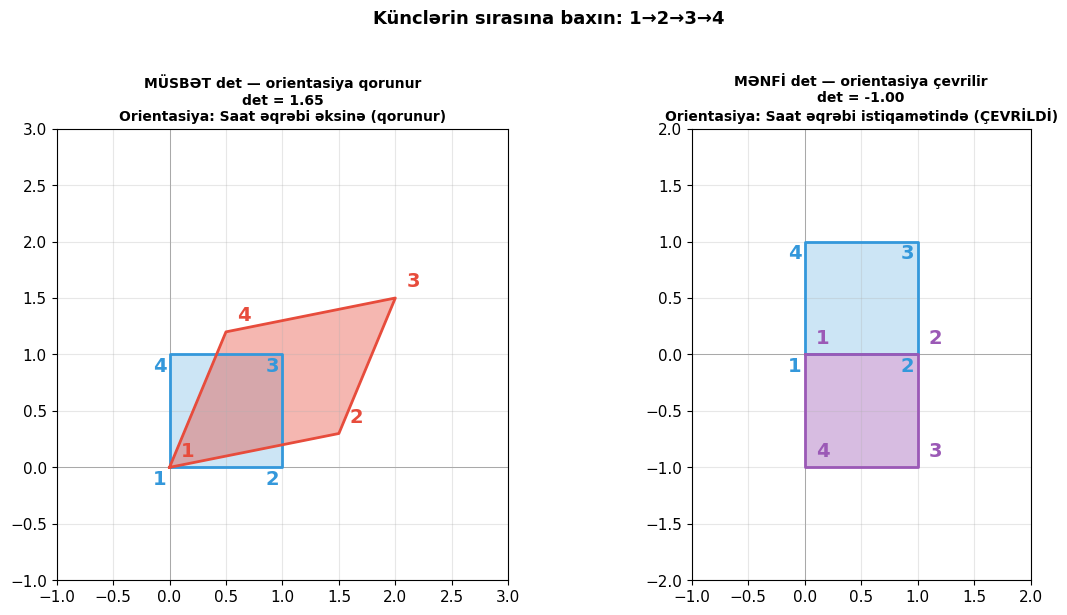

In [3]:
def plot_oriented_square(ax, M, title, color):
    """Künclərə nömrə qoyub transformasiyanı göstər."""
    # Orijinal
    plot_unit_square(ax)
    corners_orig = np.array([[0, 1, 1, 0], [0, 0, 1, 1]])
    for i in range(4):
        ax.annotate(str(i+1), 
                    (corners_orig[0, i], corners_orig[1, i]),
                    fontsize=14, fontweight='bold',
                    color=COLOR_ORIGINAL,
                    xytext=(-12, -12), textcoords='offset points')
    
    # Transformed
    transformed = M @ corners_orig
    # Bağlamaq üçün ilk nöqtəni təkrarla
    transformed_closed = np.column_stack([transformed, transformed[:, [0]]])
    det = np.linalg.det(M)
    
    ax.fill(transformed_closed[0], transformed_closed[1], alpha=0.4, color=color)
    ax.plot(transformed_closed[0], transformed_closed[1], '-', color=color, linewidth=2)
    
    for i in range(4):
        ax.annotate(str(i+1),
                    (transformed[0, i], transformed[1, i]),
                    fontsize=14, fontweight='bold',
                    color=color,
                    xytext=(8, 8), textcoords='offset points')
    
    # Oxlar
    ax.axhline(0, color='gray', linewidth=0.5, zorder=0)
    ax.axvline(0, color='gray', linewidth=0.5, zorder=0)
    
    orientation = 'Saat əqrəbi əksinə (qorunur)' if det > 0 else 'Saat əqrəbi istiqamətində (ÇEVRİLDİ)'
    ax.set_title(f'{title}\ndet = {det:.2f}\nOrientasiya: {orientation}',
                 fontsize=10, fontweight='bold')
    ax.set_aspect('equal')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Müsbət det
M_pos = np.array([[1.5, 0.5], [0.3, 1.2]])
plot_oriented_square(axes[0], M_pos, 'MÜSBƏT det — orientasiya qorunur', COLOR_TRANSFORMED)
axes[0].set_xlim(-1, 3)
axes[0].set_ylim(-1, 3)

# Mənfi det (reflection)
M_neg = np.array([[1, 0], [0, -1]])
plot_oriented_square(axes[1], M_neg, 'MƏNFİ det — orientasiya çevrilir', COLOR_FLIPPED)
axes[1].set_xlim(-1, 2)
axes[1].set_ylim(-2, 2)

plt.suptitle('Künclərin sırasına baxın: 1→2→3→4',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_orientation.png', dpi=120, bbox_inches='tight')
plt.show()

**📌 İzah:** Sol qrafikdə nömrələrin sırası (1→2→3→4) həm orijinalda, həm də transformasiyadan sonra **saat əqrəbinin əksinə** dövr edir — yəni yön qorunub. Sağ qrafikdə isə reflection sonrası nömrələr **saat əqrəbi istiqamətinə** keçir — bu, mənfi determinantın həndəsi mənasıdır. Bu fərqi 3D-də sağ əldən sol ələ keçmək kimi düşün — ölçü dəyişmir, amma 'chirality' (yönlük) dəyişir.

---
## 3️⃣ det = 0: Müstəvi Bir Xəttə Sıxılır

Singular matris (det=0) müstəvini **bir xəttə** sıxır. Fərqli giriş nöqtələri eyni çıxış nöqtəsinə düşür — informasiya itir.

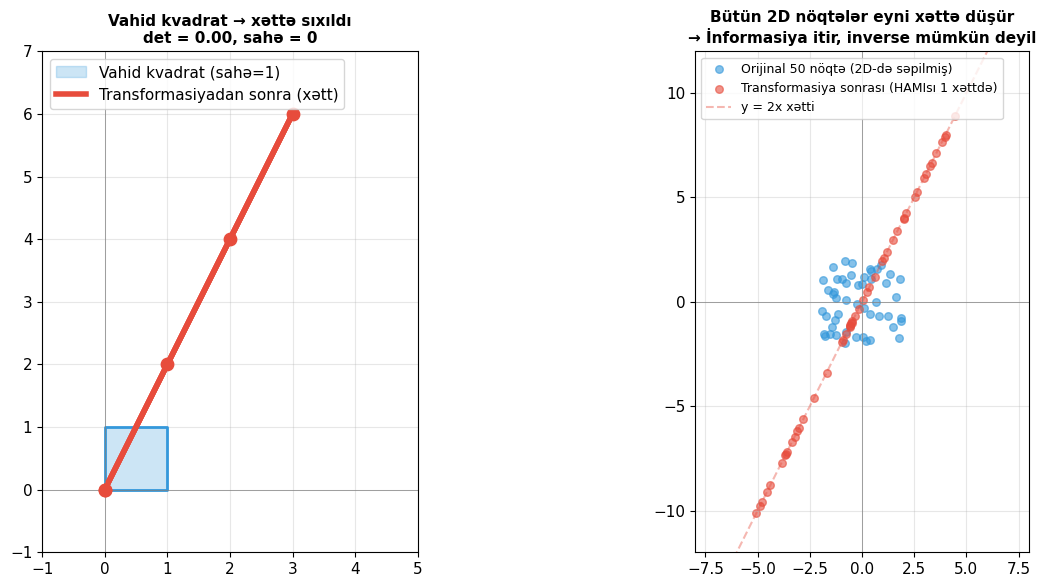

In [4]:
M_singular = np.array([[1, 2], [2, 4]])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sol: vahid kvadrat → xətt
ax = axes[0]
plot_unit_square(ax)
transformed = apply_transform(M_singular)
ax.plot(transformed[0], transformed[1], '-', color=COLOR_TRANSFORMED, linewidth=4,
        label='Transformasiyadan sonra (xətt)')
ax.scatter(transformed[0], transformed[1], color=COLOR_TRANSFORMED, s=80, zorder=5)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_title(f'Vahid kvadrat → xəttə sıxıldı\ndet = {np.linalg.det(M_singular):.2f}, sahə = 0',
             fontsize=11, fontweight='bold')
ax.set_aspect('equal')
ax.legend(loc='upper left')
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 7)

# Sağ: fərqli nöqtələrin hamısı eyni xəttə düşür
ax = axes[1]
np.random.seed(42)
n_points = 50
# Random nöqtələr çək
points = np.random.uniform(-2, 2, (2, n_points))
transformed_points = M_singular @ points

# Orijinal nöqtələr (mavi)
ax.scatter(points[0], points[1], color=COLOR_ORIGINAL, s=30, alpha=0.6, 
           label=f'Orijinal {n_points} nöqtə (2D-də səpilmiş)')
# Transformed nöqtələr (qırmızı) — hamısı bir xəttdə
ax.scatter(transformed_points[0], transformed_points[1], color=COLOR_TRANSFORMED,
           s=30, alpha=0.6, label='Transformasiya sonrası (HAMIsı 1 xəttdə)')

# Xətti göstər
t = np.linspace(-15, 15, 100)
ax.plot(t, 2*t, '--', color=COLOR_TRANSFORMED, alpha=0.4, label='y = 2x xətti')

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_title('Bütün 2D nöqtələr eyni xəttə düşür\n→ İnformasiya itir, inverse mümkün deyil',
             fontsize=11, fontweight='bold')
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(-8, 8)
ax.set_ylim(-12, 12)

plt.tight_layout()
plt.savefig('03_singular.png', dpi=120, bbox_inches='tight')
plt.show()

**📌 İzah:** Sol qrafikdə vahid kvadrat (mavi) bir **düz xəttə** çevrilir — sahə tamamilə yox olur. Sağ qrafikdə 50 random nöqtə götürülüb (mavi), və hamısı transformasiyadan sonra eyni xətt (y=2x) üstünə düşür (qırmızı). Bu, **inverse-in niyə mümkün olmadığını** birbaşa göstərir: eyni çıxış nöqtəsindən fərqli giriş nöqtələrinə geri qayıtmaq olmur.

---
## 4️⃣ Column Space — A·v Vektorlarının Toplandığı Yer

**Column space** = matrisin çıxara biləcəyi bütün vektorların çoxluğu. Singular matris üçün bu **bir xəttdir**.

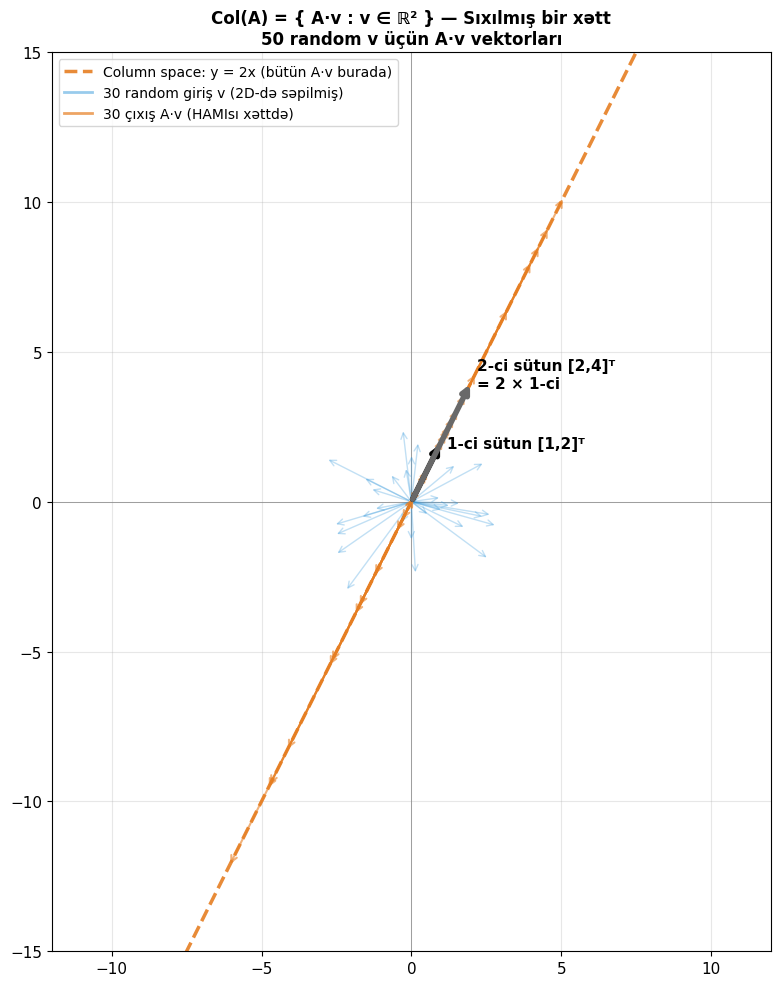

In [5]:
M = np.array([[1, 2], [2, 4]])

fig, ax = plt.subplots(figsize=(10, 10))

# Sol tərəfdə: random v vektorları (giriş)
# Sağ tərəfdə: A·v vektorları (çıxış)
# Hamısı eyni qrafikdə amma fərqli rənglərlə

np.random.seed(7)
n_vectors = 30
v_vectors = np.random.uniform(-3, 3, (2, n_vectors))
Av_vectors = M @ v_vectors

# Giriş vektorları (mavi, açıq) — 2D-də səpilmiş
for i in range(n_vectors):
    ax.annotate('', xy=(v_vectors[0, i], v_vectors[1, i]), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=COLOR_ORIGINAL, alpha=0.3, lw=1))

# Çıxış vektorları (narıncı) — hamısı xəttdə
for i in range(n_vectors):
    ax.annotate('', xy=(Av_vectors[0, i], Av_vectors[1, i]), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=COLOR_COLUMN, alpha=0.6, lw=1.5))

# Column space xətti (y = 2x)
t = np.linspace(-20, 20, 100)
ax.plot(t, 2*t, '--', color=COLOR_COLUMN, linewidth=2.5, alpha=0.9,
        label='Column space: y = 2x (bütün A·v burada)')

# Sütun vektorlarını qalın çək
ax.annotate('', xy=(1, 2), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='black', lw=4))
ax.annotate('1-ci sütun [1,2]ᵀ', (1.2, 1.8), fontsize=11, fontweight='bold')

ax.annotate('', xy=(2, 4), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='dimgray', lw=4))
ax.annotate('2-ci sütun [2,4]ᵀ\n= 2 × 1-ci', (2.2, 3.8), fontsize=11, fontweight='bold')

# Legend üçün dummy lines
ax.plot([], [], '-', color=COLOR_ORIGINAL, alpha=0.5, linewidth=2,
        label=f'{n_vectors} random giriş v (2D-də səpilmiş)')
ax.plot([], [], '-', color=COLOR_COLUMN, alpha=0.7, linewidth=2,
        label=f'{n_vectors} çıxış A·v (HAMIsı xəttdə)')

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_title(f'Col(A) = {{ A·v : v ∈ ℝ² }} — Sıxılmış bir xətt\n50 random v üçün A·v vektorları',
             fontsize=12, fontweight='bold')
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(-12, 12)
ax.set_ylim(-15, 15)

plt.tight_layout()
plt.savefig('04_column_space.png', dpi=120, bbox_inches='tight')
plt.show()

**📌 İzah:** 50 fərqli random vektor üçün A·v hesablandı və hamısı **eyni xətt boyunca** uzanır. Bu xətt y=2x xəttidir — yəni 1-ci sütunun (qara ox) span-i. 2-ci sütun (boz ox) 1-cinin sadəcə ikiqat versiyasıdır deyə yeni istiqamət gətirmir. **Column space-in dimension-ı = 1**, bu da matrisin rank-i ilə eyni şeydir.

---
## 5️⃣ Null Space — A·v = 0 Olan Vektorlar

**Null space** = matrislə vurulduqda sıfır vektora çevrilən vektorlar. Bu, matrisin "sildiyi" istiqamətlərdir.

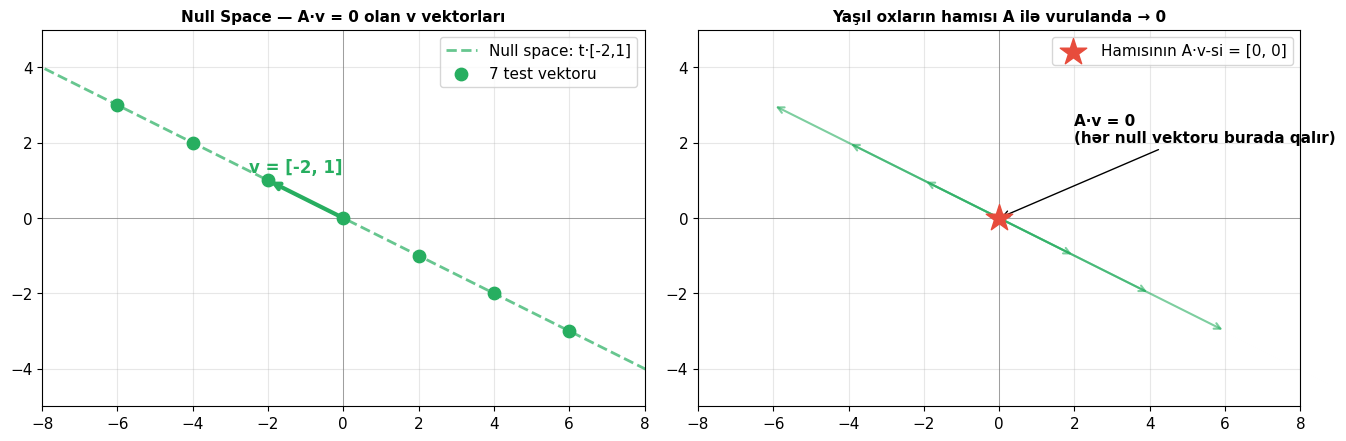

Yoxlama — null space-dəki vektorların A·v-si:
  v = [-2  1],  A·v = [0 0]
  v = [-4  2],  A·v = [0 0]
  v = [ 3.  -1.5],  A·v = [0. 0.]
  v = [-6  3],  A·v = [0 0]


In [6]:
M = np.array([[1, 2], [2, 4]])

# Null space: x + 2y = 0  ⟹  v = t·[-2, 1]
null_direction = np.array([-2, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Sol: null space xətti və üzərində nöqtələr
ax = axes[0]
t_vals = np.linspace(-3, 3, 7)
null_points = np.outer(null_direction, t_vals)

# Null space xətti
t_line = np.linspace(-15, 15, 100)
ax.plot(t_line * null_direction[0], t_line * null_direction[1],
        '--', color=COLOR_NULL, linewidth=2, alpha=0.7,
        label='Null space: t·[-2,1]')

# Test nöqtələri
ax.scatter(null_points[0], null_points[1], color=COLOR_NULL, s=80, zorder=5,
           label=f'{len(t_vals)} test vektoru')

# Bir konkret vektoru ox kimi göstər
ax.annotate('', xy=(-2, 1), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color=COLOR_NULL, lw=3))
ax.annotate('v = [-2, 1]', (-2.5, 1.2), fontsize=12, fontweight='bold', color=COLOR_NULL)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_title('Null Space — A·v = 0 olan v vektorları',
             fontsize=11, fontweight='bold')
ax.set_aspect('equal')
ax.legend(loc='upper right')
ax.set_xlim(-8, 8)
ax.set_ylim(-5, 5)

# Sağ: bu vektorların hər biri 0-a düşür
ax = axes[1]
# Orijinal null vektorları
for i, t in enumerate(t_vals):
    v = t * null_direction
    Av = M @ v
    if t != 0:
        ax.annotate('', xy=(v[0], v[1]), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=COLOR_NULL, alpha=0.6, lw=1.5))

# Hamısının A·v-si sıfırdır — origində qalın nöqtə
ax.scatter([0], [0], s=400, color=COLOR_TRANSFORMED, zorder=10, marker='*',
           label='Hamısının A·v-si = [0, 0]')

ax.annotate('A·v = 0\n(hər null vektoru burada qalır)',
            xy=(0, 0), xytext=(2, 2),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=11, fontweight='bold')

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_title('Yaşıl oxların hamısı A ilə vurulanda → 0',
             fontsize=11, fontweight='bold')
ax.set_aspect('equal')
ax.legend(loc='upper right')
ax.set_xlim(-8, 8)
ax.set_ylim(-5, 5)

plt.tight_layout()
plt.savefig('05_null_space.png', dpi=120, bbox_inches='tight')
plt.show()

# Yoxlama
print("Yoxlama — null space-dəki vektorların A·v-si:")
for t in [1, 2, -1.5, 3]:
    v = t * null_direction
    Av = M @ v
    print(f"  v = {v},  A·v = {Av}")

**📌 İzah:** Sol qrafikdə null space xətti (yaşıl punktir) — bütün $v = t \cdot [-2, 1]$ vektorları. Sağ qrafikdə həmin vektorların hamısı matrislə vurulanda **eyni nöqtəyə (origin)** düşür. Bu, matrisin "sildiyi" istiqamətdir. **Column space və null space bir-birinə perpendikulyardır** — diqqət et: column space istiqaməti [1,2], null space istiqaməti [-2,1], onların skalyar hasili = -2+2 = 0.

---
## 6️⃣ Determinant Signum Cədvəli

5 fərqli matris üçün det işarəsinin orientasiyaya təsirini bir cədvəldə göstərək.

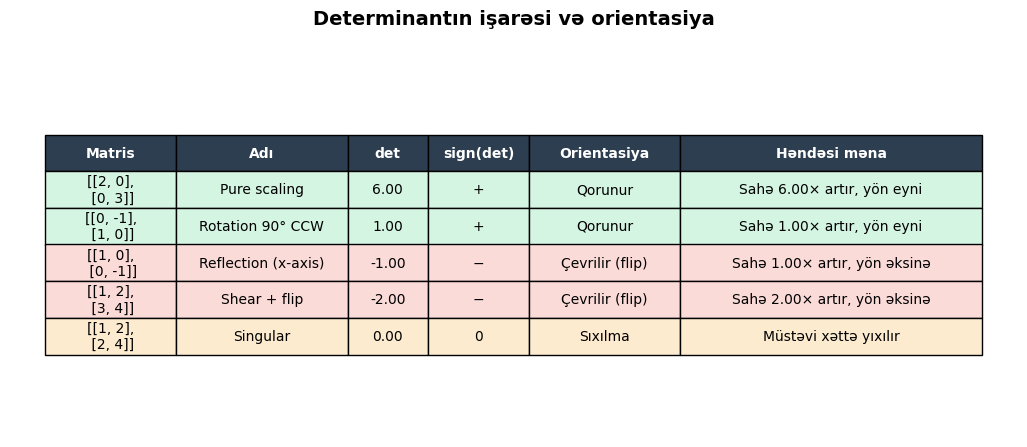

In [7]:
matrices_table = [
    (np.array([[2, 0], [0, 3]]),    'Pure scaling'),
    (np.array([[0, -1], [1, 0]]),   'Rotation 90° CCW'),
    (np.array([[1, 0], [0, -1]]),   'Reflection (x-axis)'),
    (np.array([[1, 2], [3, 4]]),    'Shear + flip'),
    (np.array([[1, 2], [2, 4]]),    'Singular'),
]

fig, ax = plt.subplots(figsize=(13, 5))
ax.axis('off')

# Cədvəl məlumatları
headers = ['Matris', 'Adı', 'det', 'sign(det)', 'Orientasiya', 'Həndəsi məna']
rows = []
for M, name in matrices_table:
    det = np.linalg.det(M)
    sign = '+' if det > 1e-10 else ('−' if det < -1e-10 else '0')
    
    if abs(det) < 1e-10:
        orient = 'Sıxılma'
        meaning = 'Müstəvi xəttə yıxılır'
    elif det > 0:
        orient = 'Qorunur'
        meaning = f'Sahə {abs(det):.2f}× artır, yön eyni'
    else:
        orient = 'Çevrilir (flip)'
        meaning = f'Sahə {abs(det):.2f}× artır, yön əksinə'
    
    matrix_str = f'[[{M[0,0]:.0f}, {M[0,1]:.0f}],\n [{M[1,0]:.0f}, {M[1,1]:.0f}]]'
    rows.append([matrix_str, name, f'{det:.2f}', sign, orient, meaning])

# Cədvəl çək
table = ax.table(cellText=rows, colLabels=headers,
                  cellLoc='center', loc='center',
                  colWidths=[0.13, 0.17, 0.08, 0.10, 0.15, 0.30])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Başlıq satırını rəngləndir
for i in range(len(headers)):
    cell = table[(0, i)]
    cell.set_facecolor('#2c3e50')
    cell.set_text_props(color='white', fontweight='bold')

# Sətirləri sign-ə görə rəngləndir
for row_idx, row in enumerate(rows, start=1):
    sign = row[3]
    if sign == '+':
        color = '#d5f5e3'  # açıq yaşıl
    elif sign == '−':
        color = '#fadbd8'  # açıq qırmızı
    else:
        color = '#fdebd0'  # açıq narıncı
    
    for col_idx in range(len(headers)):
        table[(row_idx, col_idx)].set_facecolor(color)

plt.title('Determinantın işarəsi və orientasiya',
          fontsize=14, fontweight='bold', pad=20)
plt.savefig('06_signum_table.png', dpi=120, bbox_inches='tight')
plt.show()

**📌 İzah:** Bu cədvəl determinantın 3 fərqli rejimini bir yerdə göstərir: **müsbət** (yaşıl) — yön qorunur, sahə dəyişir; **mənfi** (qırmızı) — yön əksinə çevrilir, sahə yenə dəyişir; **sıfır** (narıncı) — müstəvi xəttə sıxılır, sahə yox olur. ML kontekstində bu üç rejim normalizing flows, Jacobian determinantı, və invertible neural networks-də qarşımıza çıxır.

---
## 7️⃣ BONUS — Animasiya: Determinant 0-a yaxınlaşanda

Parametrik matris $M(t) = \begin{pmatrix} 1 & t \\ 0.5 & 0.5t + 0.01 \end{pmatrix}$. $t$ dəyişəndə det də dəyişir, $t \to 2$ olanda det $\to 0$, və kvadrat yastılaşır.

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))

def get_matrix(t):
    """Parametrik matris — t artanda det 0-a yaxınlaşır.
    
    M(t) = [[1, 1], [t, 1]] verir det = 1 - t.
    t=0 → det=1 (kvadrat olaraq qalır)
    t=1 → det=0 (yastılaşır)
    t=2 → det=-1 (çevrilir)
    """
    return np.array([[1.0, 1.0], [t, 1.0]])

def animate(frame):
    ax.clear()
    t = frame / 25 * 2.0  # 0-dan 2.0-yə
    M = get_matrix(t)
    det = np.linalg.det(M)
    
    # Vahid kvadrat
    plot_unit_square(ax)
    
    # Transformed
    transformed = apply_transform(M)
    color = COLOR_TRANSFORMED if det > 0.01 else (COLOR_FLIPPED if det < -0.01 else 'black')
    ax.fill(transformed[0], transformed[1], alpha=0.4, color=color)
    ax.plot(transformed[0], transformed[1], '-', color=color, linewidth=2)
    
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlim(-1, 3)
    ax.set_ylim(-1, 3)
    ax.set_aspect('equal')
    ax.set_title(f't = {t:.2f}    det(M) = {det:+.3f}    sahə = {abs(det):.3f}',
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    return ax,

anim = FuncAnimation(fig, animate, frames=26, interval=250, blit=False)
plt.close()  # Statik şəkli göstərmə

# Notebook-da göstərmək üçün
HTML(anim.to_jshtml())

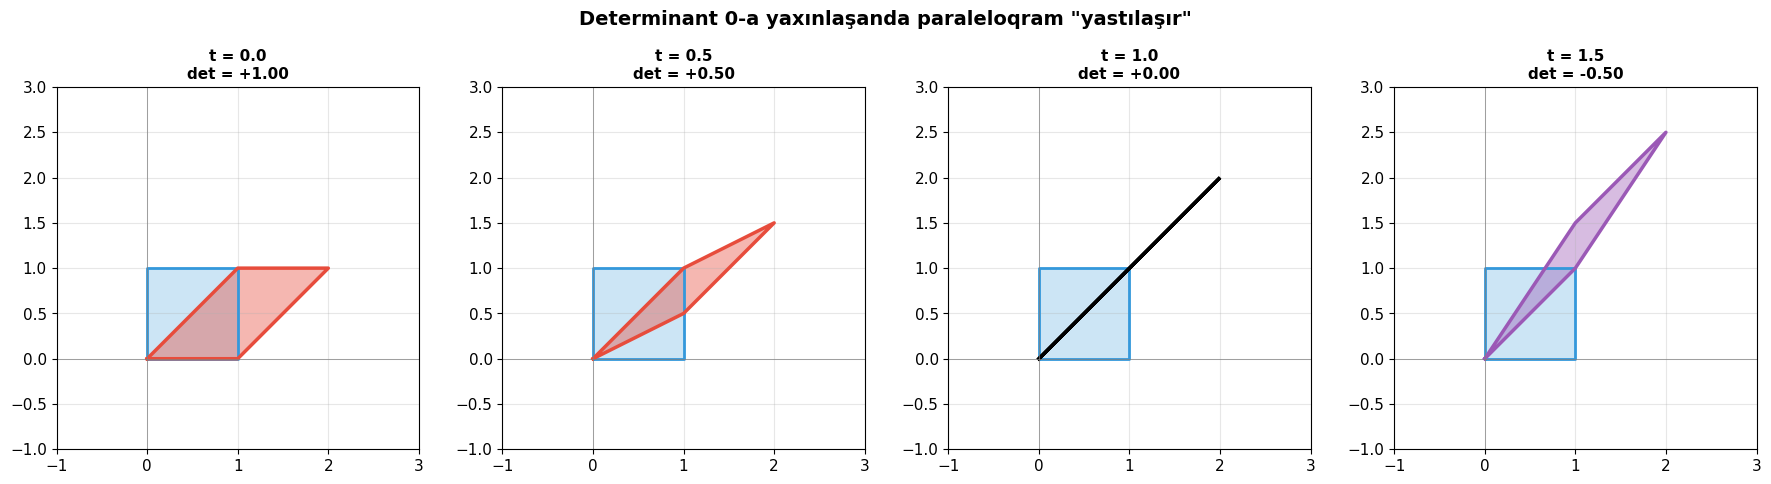

In [9]:
# Animasiyanı 4 stop-frame kimi də göstərək (statik müqayisə üçün)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

t_values = [0.0, 0.5, 1.0, 1.5]  # 0 → kvadrat, 1 → yastı, 1.5 → çevrilmiş
for ax, t in zip(axes, t_values):
    M = get_matrix(t)
    det = np.linalg.det(M)
    
    plot_unit_square(ax)
    transformed = apply_transform(M)
    color = COLOR_TRANSFORMED if det > 0.01 else (COLOR_FLIPPED if det < -0.01 else 'black')
    ax.fill(transformed[0], transformed[1], alpha=0.4, color=color)
    ax.plot(transformed[0], transformed[1], '-', color=color, linewidth=2.5)
    
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlim(-1, 3)
    ax.set_ylim(-1, 3)
    ax.set_aspect('equal')
    ax.set_title(f't = {t}\ndet = {det:+.2f}', fontsize=11, fontweight='bold')

plt.suptitle('Determinant 0-a yaxınlaşanda paraleloqram "yastılaşır"',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('07_flattening.png', dpi=120, bbox_inches='tight')
plt.show()

**📌 İzah:** t parametri 0.5-dən 2-yə doğru artır, və hər addımda determinant kiçilir. t=2 olanda det praktik olaraq sıfırdır və paraleloqram **düz xətə yıxılır**. Bu, real ML-də nə vaxt görünür? **Conditioning** — matrisin det-i nə qədər sıfıra yaxındırsa, o qədər "ill-conditioned" olur, yəni numerik həllər kobud (unstable) olur. Linear regression-da multicollinear feature-lər bu effekti yaradır.

---
## 🎯 Yekun

Bu notebook 7 fərqli vizualla determinantın həndəsi mənasını tam əhatə etdi:

| # | Vizual | Konsept |
|---|--------|---------|
| 1 | 5 transformasiya | det = sahə əmsalı |
| 2 | Künc nömrələri | det işarəsi = orientasiya |
| 3 | Müstəvi → xətt | det = 0 → informasiya itir |
| 4 | 50 A·v vektoru | Column space = sütunların span-i |
| 5 | Null space xətti | A·v = 0 olan istiqamət |
| 6 | Signum cədvəli | Bütün rejimlərin xülasəsi |
| 7 | Animasiya | Smooth transition det → 0 |

**ML kontekstində bu konseplər haradadır:**
- **Determinant** → Jacobian-da change of variables, normalizing flows
- **Orientasiya** → 3D graphics, robotics, chirality
- **Singular matris** → Multicollinearity, regularization-ın səbəbi
- **Column space** → Linear regression həll uzayı
- **Null space** → Bias term, underdetermined sistemlər

Növbəti həftə: **Eigenvectors və eigenvalues** — PCA, spectral methods, neural network stability.